<a href="https://colab.research.google.com/github/KelvinPogo/sdss_datathon_2026/blob/main/My_copy_SDSS_datathon.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
!pip install pgeocode

In [6]:
from google.colab import drive
import pandas as pd
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [7]:
import pandas as pd
file_path = '/content/drive/MyDrive/public_services_dataset.xlsx'
df = pd.read_excel(file_path)
print(df.head())

KeyboardInterrupt: 

In [ ]:
df[df["PROGRAM_MODEL"].isna()]

In [ ]:
df_clean = df.replace(r'^\s*$', pd.NA, regex=True)
rows_with_missing = df_clean[df_clean.isna().any(axis=1)]
print(len(rows_with_missing))

In [ ]:
df_new = df.drop(index=[52524, 52547, 52841, 52960])

In [ ]:
df_clean = df_new.replace(r'^\s*$', pd.NA, regex=True)
rows_with_missing = df_clean[df_clean.isna().any(axis=1)]
print(len(rows_with_missing))

In [ ]:
df_clean = df_new.replace(
    to_replace=r'^\s*(nan|NAN)\s*$',
    value=pd.NA,
    regex=True
)

In [ ]:
rows_with_missing = df_clean[df_clean.isna().any(axis=1)]
print(rows_with_missing)

In [ ]:
# Remove rows that contain at least one real NaN
df_clean = df_clean.dropna()
print("Remaining rows:", len(df_clean))

In [ ]:
df_clean.to_csv("clean_data.csv")

# Logistic Regression Model

In [8]:
import pandas as pd
import numpy as np

df = pd.read_csv("/content/clean_data.csv")

# Ensure numeric
df["OCCUPANCY_RATE"] = pd.to_numeric(df["OCCUPANCY_RATE"], errors="coerce")

# Drop any rows where occupancy rate is missing (safety)
df = df.dropna(subset=["OCCUPANCY_RATE"])

# Create critical threshold (95%)
df["CRITICAL_95"] = (df["OCCUPANCY_RATE"] >= 0.95).astype(int)

# Optional: also create extreme threshold (100%)
df["FULL_100"] = (df["OCCUPANCY_RATE"] >= 1.0).astype(int)

print("Share of critical days:", df["CRITICAL_95"].mean())
print("Share of full days:", df["FULL_100"].mean())

Share of critical days: 0.8825309692029931
Share of full days: 0.7874891725195938


In [9]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

In [10]:
# Ensure date format
df["OCCUPANCY_DATE"] = pd.to_datetime(df["OCCUPANCY_DATE"], errors="coerce")

# Create time features
df["MONTH"] = df["OCCUPANCY_DATE"].dt.month
df["DAY_OF_WEEK"] = df["OCCUPANCY_DATE"].dt.dayofweek

# Select features
features = [
    "ACTUAL_CAPACITY",
    "UNAVAILABLE_CAPACITY",
    "MONTH",
    "DAY_OF_WEEK",
    "SECTOR",
    "OVERNIGHT_SERVICE_TYPE",
    "PROGRAM_MODEL"
]

X = df[features]
y = df["CRITICAL_95"]

# One-hot encode categoricals
X = pd.get_dummies(X, drop_first=True)

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [12]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [13]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

              precision    recall  f1-score   support

           0       0.53      0.03      0.06      2295
           1       0.88      1.00      0.94     16870

    accuracy                           0.88     19165
   macro avg       0.70      0.51      0.50     19165
weighted avg       0.84      0.88      0.83     19165

ROC-AUC: 0.8076938603933965


In [14]:
model = LogisticRegression(max_iter=1000, class_weight="balanced")
model.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [15]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

              precision    recall  f1-score   support

           0       0.32      0.78      0.46      2295
           1       0.96      0.78      0.86     16870

    accuracy                           0.78     19165
   macro avg       0.64      0.78      0.66     19165
weighted avg       0.89      0.78      0.81     19165

ROC-AUC: 0.8072553668770412


In [16]:
!pip install xgboost

In [17]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    scale_pos_weight=(len(y_train[y_train==0]) / len(y_train[y_train==1])),
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

xgb.fit(X_train, y_train)

y_pred = xgb.predict(X_test)
y_prob = xgb.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [16:17:14] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


              precision    recall  f1-score   support

           0       0.53      0.93      0.67      2295
           1       0.99      0.89      0.93     16870

    accuracy                           0.89     19165
   macro avg       0.76      0.91      0.80     19165
weighted avg       0.93      0.89      0.90     19165

ROC-AUC: 0.9646766442861148


In [18]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.model_selection import train_test_split

# Train-test split (use same split as before if possible)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
y_proba = rf.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))

              precision    recall  f1-score   support

           0       0.58      0.80      0.67      2251
           1       0.97      0.92      0.95     16914

    accuracy                           0.91     19165
   macro avg       0.78      0.86      0.81     19165
weighted avg       0.93      0.91      0.91     19165

ROC-AUC: 0.9377493176734821


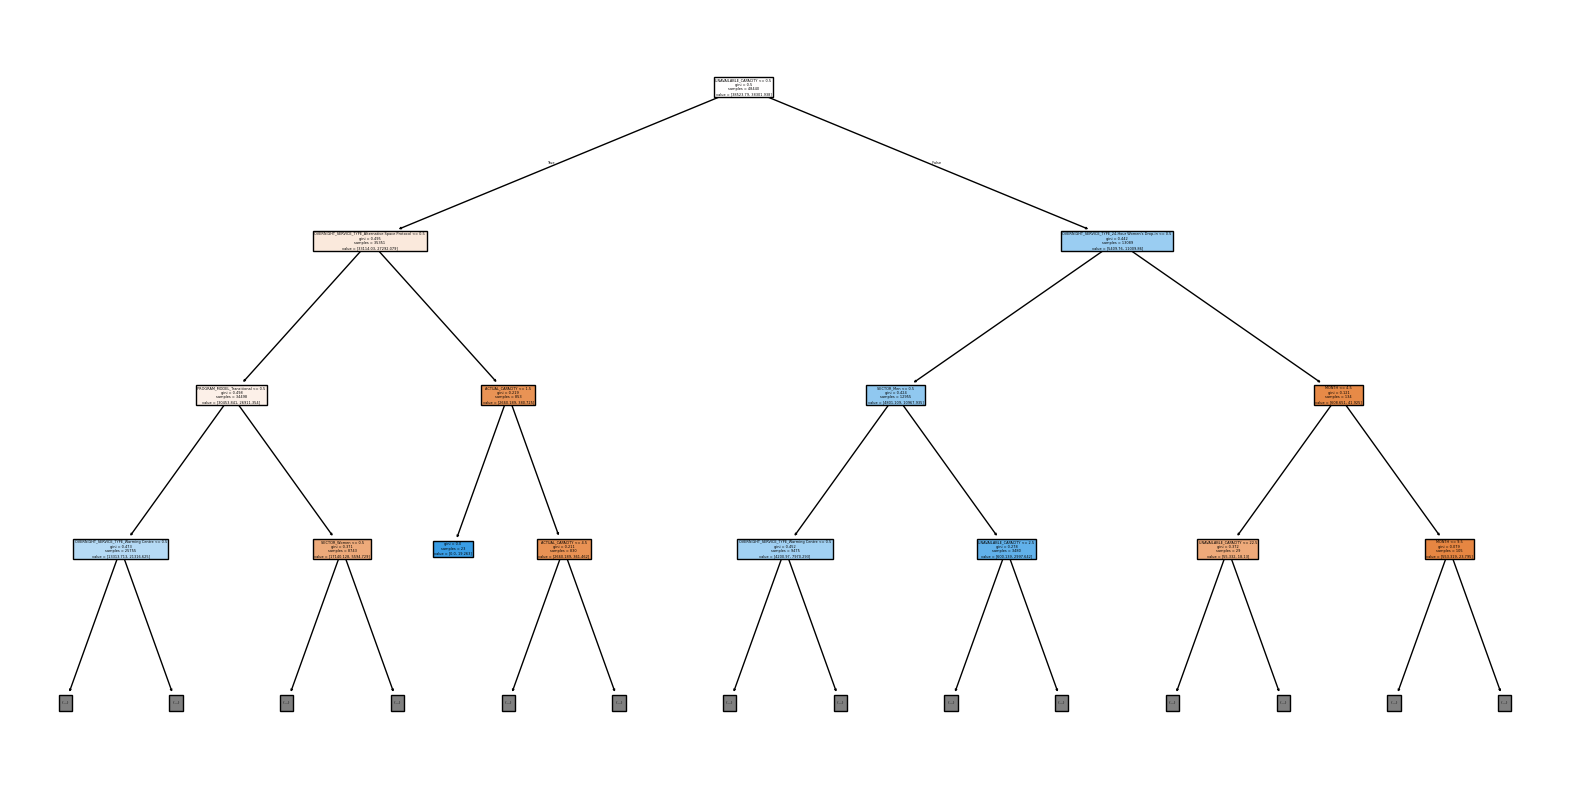

In [20]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
plt.figure(figsize=(20, 10))
plot_tree(rf.estimators_[0], feature_names=X.columns, filled=True, max_depth=3)
plt.show()

In [21]:
[estimator.tree_.max_depth for estimator in rf.estimators_]

[28,
 29,
 29,
 26,
 27,
 28,
 29,
 24,
 27,
 28,
 29,
 25,
 31,
 28,
 26,
 25,
 31,
 30,
 26,
 28,
 28,
 25,
 25,
 26,
 26,
 28,
 27,
 25,
 31,
 28,
 26,
 27,
 24,
 26,
 28,
 28,
 24,
 28,
 29,
 26,
 26,
 27,
 25,
 24,
 27,
 27,
 27,
 28,
 26,
 25,
 26,
 29,
 26,
 26,
 25,
 25,
 26,
 24,
 26,
 25,
 26,
 28,
 25,
 26,
 29,
 28,
 25,
 28,
 26,
 26,
 25,
 26,
 26,
 32,
 29,
 26,
 25,
 26,
 28,
 29,
 27,
 27,
 27,
 26,
 26,
 26,
 27,
 25,
 26,
 28,
 24,
 28,
 24,
 25,
 30,
 29,
 26,
 24,
 25,
 27,
 26,
 30,
 29,
 26,
 25,
 27,
 27,
 24,
 28,
 27,
 28,
 29,
 27,
 27,
 27,
 27,
 26,
 26,
 30,
 28,
 30,
 31,
 26,
 27,
 25,
 28,
 28,
 26,
 30,
 26,
 26,
 26,
 29,
 25,
 26,
 26,
 28,
 25,
 26,
 29,
 27,
 26,
 24,
 27,
 27,
 27,
 26,
 25,
 29,
 27,
 25,
 26,
 29,
 24,
 25,
 26,
 28,
 29,
 26,
 28,
 26,
 25,
 26,
 26,
 26,
 29,
 28,
 26,
 29,
 26,
 26,
 25,
 29,
 27,
 25,
 28,
 28,
 24,
 27,
 27,
 26,
 28,
 26,
 26,
 26,
 25,
 24,
 27,
 25,
 27,
 28,
 31,
 25,
 27,
 25,
 28,
 25,
 25,
 28,
 24,
